

# Live Generalize Womack
### OPIM 5641 — Business Decision Modeling · Module4

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5641-notebooks/blob/main/7_Nonlinear/Live_GeneralizeWomack.ipynb)

*Run me top to bottom — **Runtime → Run all**. Data loads from a stable link, so there's nothing to upload.*

# Generalize Womack

# Download the solver

In [1]:
%%capture
import sys
import os

if 'google.colab' in sys.modules:
    !pip install idaes-pse --pre
    !idaes get-extensions --to ./bin
    os.environ['PATH'] += ':bin'

# Import modules

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Download data

## Ms. Womack data

In [3]:
# read a .csv file of returns
# make sure you navigate to your file and update the path!
# Save the link you were given in a variable
URL = 'https://drive.google.com/file/d/1Nixf7roe8lfi9U514jOrbqrCRDAHW77o/view?usp=sharing'
# You will need the line below to indicate that you will download the content of the link
fixed_path = 'https://drive.google.com/uc?export=download&id='
# Extract the file ID from the URL
file_path = URL.split('/')[-2]

df = pd.read_csv(fixed_path + file_path)
df.head()

,Month,Computer,Chemical,Power,Auto,Electronic
0,1,0.22816,-0.07205,0.01730,0.22266,0.08202
1,2,0.09134,0.02588,0.05646,0.01278,-0.03499
2,3,-0.01288,-0.04771,0.02280,0.00379,0.01662
3,4,-0.17196,0.06342,0.00000,0.04101,-0.07496
4,5,0.16557,0.03670,0.00510,0.07576,-0.00810


## Real-World Data

In [4]:
# https://drive.google.com/file/d/1OBA00SvkDZVKhcGgyrD49zP5qZNfLdmT/view?usp=sharing
!gdown 1OBA00SvkDZVKhcGgyrD49zP5qZNfLdmT

Downloading...
From: https://drive.google.com/uc?id=1OBA00SvkDZVKhcGgyrD49zP5qZNfLdmT
To: /content/mydata.csv
100% 75.0k/75.0k [00:00<00:00, 22.8MB/s]


In [5]:
# F25
# https://drive.google.com/file/d/1YbUaP6XY6kU4wIOQKhw2mTVYgtWPDAVR/view?usp=sharing
!gdown 1YbUaP6XY6kU4wIOQKhw2mTVYgtWPDAVR

Downloading...
From: https://drive.google.com/uc?id=1YbUaP6XY6kU4wIOQKhw2mTVYgtWPDAVR
To: /content/mydata_monthly.csv
100% 9.05k/9.05k [00:00<00:00, 20.0MB/s]


In [6]:
df = pd.read_csv('mydata_monthly.csv')

In [7]:
df.head()

,Date,NFLX,IBM,GE,GOOG,AAPL,KO,AMZN,HD,NKE,WMT,BTC-USD
0,2022-10-31,0.239721,0.163959,0.256825,-0.015497,0.109552,0.068368,-0.093451,0.073168,0.115014,0.097378,0.054755
1,2022-11-30,0.046766,0.089560,0.104871,0.071730,-0.033028,0.070362,-0.057595,0.100699,0.183535,0.070892,-0.162336
2,2022-12-31,-0.034857,-0.053794,-0.024416,-0.125382,-0.122273,0.000000,-0.129894,-0.025093,0.070008,-0.066235,-0.032966
3,2023-01-31,0.200013,-0.043722,0.230396,0.125549,0.110521,-0.036001,0.227738,0.026309,0.088198,0.014669,0.393716
4,2023-02-28,-0.089668,-0.028515,0.052559,-0.095825,0.023183,-0.029517,-0.086299,-0.085233,-0.067070,-0.012094,0.000349


In [8]:
df = df.iloc[:,1:]
df.head()

,NFLX,IBM,GE,GOOG,AAPL,KO,AMZN,HD,NKE,WMT,BTC-USD
0,0.239721,0.163959,0.256825,-0.015497,0.109552,0.068368,-0.093451,0.073168,0.115014,0.097378,0.054755
1,0.046766,0.089560,0.104871,0.071730,-0.033028,0.070362,-0.057595,0.100699,0.183535,0.070892,-0.162336
2,-0.034857,-0.053794,-0.024416,-0.125382,-0.122273,0.000000,-0.129894,-0.025093,0.070008,-0.066235,-0.032966
3,0.200013,-0.043722,0.230396,0.125549,0.110521,-0.036001,0.227738,0.026309,0.088198,0.014669,0.393716
4,-0.089668,-0.028515,0.052559,-0.095825,0.023183,-0.029517,-0.086299,-0.085233,-0.067070,-0.012094,0.000349


# 🔵 ConcreteModel

In [9]:
from pyomo.environ import *

# Initialize model
m = ConcreteModel()



In [10]:
df.head()

,NFLX,IBM,GE,GOOG,AAPL,KO,AMZN,HD,NKE,WMT,BTC-USD
0,0.239721,0.163959,0.256825,-0.015497,0.109552,0.068368,-0.093451,0.073168,0.115014,0.097378,0.054755
1,0.046766,0.089560,0.104871,0.071730,-0.033028,0.070362,-0.057595,0.100699,0.183535,0.070892,-0.162336
2,-0.034857,-0.053794,-0.024416,-0.125382,-0.122273,0.000000,-0.129894,-0.025093,0.070008,-0.066235,-0.032966
3,0.200013,-0.043722,0.230396,0.125549,0.110521,-0.036001,0.227738,0.026309,0.088198,0.014669,0.393716
4,-0.089668,-0.028515,0.052559,-0.095825,0.023183,-0.029517,-0.086299,-0.085233,-0.067070,-0.012094,0.000349


In [11]:
df.describe()

,NFLX,IBM,GE,GOOG,AAPL,KO,AMZN,HD,NKE,WMT,BTC-USD
count,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000
mean,0.045891,0.030997,0.059857,0.032107,0.020176,0.008355,0.024674,0.012365,-0.001794,0.025046,0.055133
std,0.098178,0.076152,0.084388,0.078531,0.065676,0.042309,0.081067,0.064299,0.092851,0.051835,0.146403
min,-0.134214,-0.141224,-0.089087,-0.162354,-0.122273,-0.091149,-0.129894,-0.128728,-0.203950,-0.107280,-0.176085
25%,-0.015595,-0.028263,0.009008,-0.015184,-0.032378,-0.013060,-0.032007,-0.027467,-0.066513,-0.009115,-0.040554
50%,0.044450,0.031025,0.043708,0.036737,0.019488,0.009573,0.028929,0.007956,0.018759,0.017310,0.044937
75%,0.113201,0.089542,0.102261,0.085734,0.060150,0.028167,0.082803,0.072248,0.062276,0.059072,0.111964
max,0.239721,0.163959,0.256825,0.157134,0.130222,0.121771,0.227738,0.108557,0.183535,0.128737,0.437169


# 🔵 Decision Vars

In [12]:

# Load data
import pandas as pd
# df = df.set_index("Month")

# Asset list
assets = df.columns.tolist()
m.Assets = Set(initialize=assets)

# Define decision variables for each asset
m.x = Var(m.Assets, within=NonNegativeReals, bounds=(0,1))

In [13]:
# Covariance matrix (Sigma)
cov_df = df.cov()
cov_dict = {(i, j): cov_df.loc[i, j] for i in assets for j in assets}
m.Sigma = Param(m.Assets, m.Assets, initialize=cov_dict)

In [14]:
m.pprint()

1 Set Declarations
    Assets : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :   11 : {'NFLX', 'IBM', 'GE', 'GOOG', 'AAPL', 'KO', 'AMZN', 'HD', 'NKE', 'WMT', 'BTC-USD'}

1 Param Declarations
    Sigma : Size=121, Index=Assets*Assets, Domain=Any, Default=None, Mutable=False
        Key                    : Value
              ('AAPL', 'AAPL') :   0.004313279248347187
              ('AAPL', 'AMZN') :  0.0018002765176981376
           ('AAPL', 'BTC-USD') :  0.0012714362353306375
                ('AAPL', 'GE') :  0.0010420106128400783
              ('AAPL', 'GOOG') :  0.0019894936944336223
                ('AAPL', 'HD') :  0.0012852819334322808
               ('AAPL', 'IBM') :  0.0009770017030040381
                ('AAPL', 'KO') :  0.0005641612834701012
              ('AAPL', 'NFLX') :   0.002250131125205555
               ('AAPL', 'NKE') :   0.001008304589987942
               ('AAPL', 'WMT') :  0.0008341091572661284
 

# 🔵 Objective Fn

In [15]:
# Calculate average returns per asset
avg_returns = df.mean().to_dict()

# Create a Pyomo Param from this
m.mu = Param(m.Assets, initialize=avg_returns)


In [16]:
# Objective: Maximize expected return
def total_return(m):
    return sum(m.mu[a] * m.x[a] for a in m.Assets)

m.objective = Objective(rule=total_return, sense=maximize)


In [17]:
m.pprint()

1 Set Declarations
    Assets : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :   11 : {'NFLX', 'IBM', 'GE', 'GOOG', 'AAPL', 'KO', 'AMZN', 'HD', 'NKE', 'WMT', 'BTC-USD'}

2 Param Declarations
    Sigma : Size=121, Index=Assets*Assets, Domain=Any, Default=None, Mutable=False
        Key                    : Value
              ('AAPL', 'AAPL') :   0.004313279248347187
              ('AAPL', 'AMZN') :  0.0018002765176981376
           ('AAPL', 'BTC-USD') :  0.0012714362353306375
                ('AAPL', 'GE') :  0.0010420106128400783
              ('AAPL', 'GOOG') :  0.0019894936944336223
                ('AAPL', 'HD') :  0.0012852819334322808
               ('AAPL', 'IBM') :  0.0009770017030040381
                ('AAPL', 'KO') :  0.0005641612834701012
              ('AAPL', 'NFLX') :   0.002250131125205555
               ('AAPL', 'NKE') :   0.001008304589987942
               ('AAPL', 'WMT') :  0.0008341091572661284
 

# 🔵 Constraints

## Sum to 1

In [18]:
def budget_constraint(m):
    return sum(m.x[a] for a in m.Assets) == 1

m.budget = Constraint(rule=budget_constraint)


## Must be non-zero

In [19]:
def dummy_total_risk_rule(m):
    return sum(m.x[a] for a in m.Assets) >= 0.0

m.total_risk = Constraint(rule=dummy_total_risk_rule)

# Sum weighted cov matrix

In [20]:
ipopt_executable = '/content/bin/ipopt'

In [21]:
from pyomo.opt import SolverFactory, TerminationCondition

# Risk thresholds to test
max_risk = 0.01 #0.001 on real data? .01 on womack - need more robust soln
risk_limits = np.arange(0.00001, max_risk, 0.000005)

# Result storage
param_analysis = {}
returns = {}

# Define solver
solver = SolverFactory("ipopt", executable=ipopt_executable)

for r in risk_limits:
    # Remove old variance constraint if it exists
    if hasattr(m, 'variance_constraint'):
        m.del_component(m.variance_constraint)

    # Add new variance constraint for this risk level
    def variance_constraint_rule(m):
        return sum(m.Sigma[i, j] * m.x[i] * m.x[j] for i in m.Assets for j in m.Assets) <= r
    m.variance_constraint = Constraint(rule=variance_constraint_rule)

    # Solve
    result = solver.solve(m)

    # Skip infeasible solutions
    if result.solver.termination_condition == TerminationCondition.infeasible:
        continue

    # Save allocations and returns
    param_analysis[r] = [m.x[a]() for a in m.Assets]
    returns[r] = sum(m.mu[a] * m.x[a]() for a in m.Assets)


  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasible point. Problem may be infeasible.
  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasible point. Problem may be infeasible.
  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasible point. Problem may be infeasible.
  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasible point. Problem may be infeasible.
  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasible point. Problem may be infeasible.
  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasible point. Problem may be infeasible.
  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasibl

# Results

In [22]:
import pandas as pd

# Create DataFrame for plotting
df_results = pd.DataFrame({
    'Risk': list(returns.keys()),
    'Return': list(returns.values())
})

# Sort by Risk (just in case)
df_results = df_results.sort_values(by='Risk')


In [23]:
df_results.head(n=10)

,Risk,Return
0,0.000200,0.017075
1,0.000885,0.017862
2,0.000890,0.018288
3,0.000895,0.018601
4,0.000900,0.018867
5,0.000905,0.019105
6,0.000910,0.019321
7,0.000915,0.019522
8,0.000920,0.019716
9,0.000925,0.019904


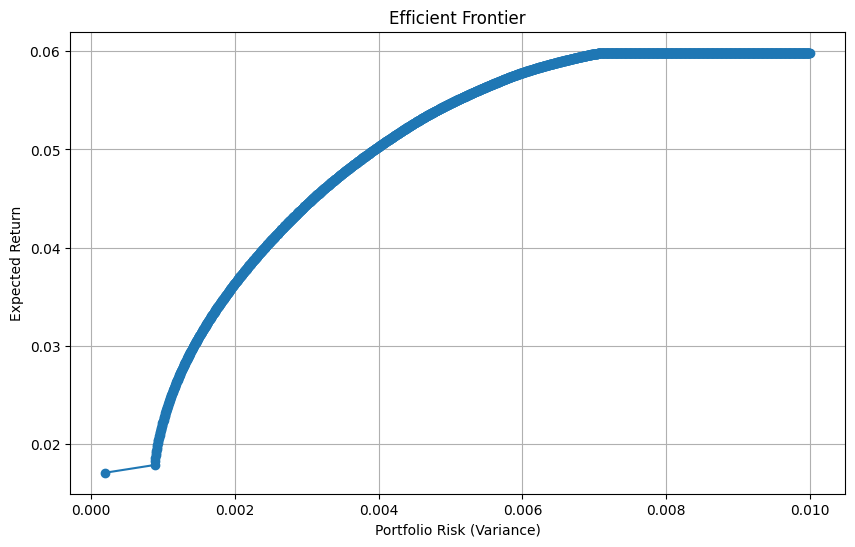

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(df_results['Risk'], df_results['Return'], marker='o', linestyle='-')
plt.title("Efficient Frontier")
plt.xlabel("Portfolio Risk (Variance)")
plt.ylabel("Expected Return")
plt.grid(True)
plt.show()


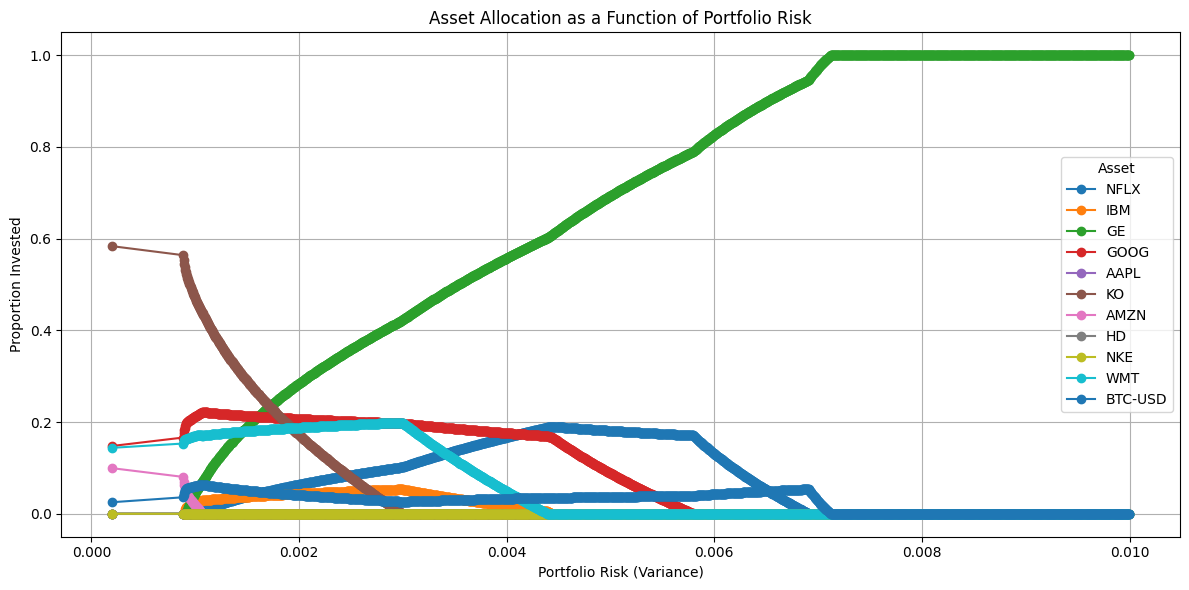

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert allocation results to DataFrame
df_allocations = pd.DataFrame(param_analysis).T  # rows = risk, columns = assets
df_allocations.columns = assets
df_allocations['Risk'] = df_allocations.index

# Plot allocation proportions by asset
plt.figure(figsize=(12, 6))
for asset in assets:
    plt.plot(df_allocations['Risk'], df_allocations[asset], label=asset, marker='o')

plt.title("Asset Allocation as a Function of Portfolio Risk")
plt.xlabel("Portfolio Risk (Variance)")
plt.ylabel("Proportion Invested")
plt.legend(title="Asset")
plt.grid(True)
plt.tight_layout()
plt.show()


In [26]:
df_allocations.head()

,NFLX,IBM,GE,GOOG,AAPL,KO,AMZN,HD,NKE,WMT,BTC-USD,Risk
0.000200,0.000000e+00,0.000000e+00,0.000000e+00,0.147890,0.000000e+00,0.583656,0.099502,0.000000e+00,0.000000e+00,0.143881,0.025242,0.000200
0.000885,3.483123e-08,2.192939e-07,3.502080e-08,0.166309,1.519057e-07,0.563967,0.080432,7.791107e-08,3.107556e-08,0.153241,0.036050,0.000885
0.000890,7.506949e-08,1.172068e-06,9.427492e-08,0.176263,2.409460e-07,0.553393,0.070151,1.089228e-07,4.517763e-08,0.158306,0.041884,0.000890
0.000895,3.468438e-08,1.898239e-03,5.997510e-08,0.182943,1.032027e-07,0.545516,0.062934,3.861156e-08,1.276264e-08,0.160835,0.045874,0.000895
0.000900,4.686613e-08,5.909535e-03,1.105805e-07,0.187843,1.195541e-07,0.538656,0.057200,4.105759e-08,1.447131e-08,0.161486,0.048906,0.000900
